<a href="https://colab.research.google.com/github/Kevin-gram/Sentiment-Analysis/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import all necessary libraries

Imports necessary libraries like pandas, scikit-learn, nltk, re, matplotlib, and seaborn for data manipulation, model building, text processing, and visualization.

In [ ]:
# importing necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import re
import matplotlib.pyplot as plt
import seaborn as sns

Loads the dataset from a CSV file named 'hate.csv' using pandas and displays its shape (number of rows and columns).

In [ ]:
# Load the dataset
dataset = pd.read_csv('hate.csv', encoding='latin-1')
dataset.shape

(41144, 3)

 Shows the first few rows of the dataset using head().

In [ ]:
dataset.head()

,Unnamed: 0,comment,label
0,1,dalits are lowlives,N
1,2,gay people are a burden to our society,N
2,3,Arabs are not welcome,N
3,4,I'm not saying we should actually eliminate he...,N
4,5,bananas are for black people,N


Displays the last few rows of the dataset using tail().

In [ ]:
dataset.tail()

,Unnamed: 0,comment,label
41139,117100,Indian culture is so backwards,N
41140,118100,"Women don't want equality, they just want to b...",N
41141,119100,fuck covid,P
41142,1205,This computer is garbage,P
41143,121100,The only good Muslim is a dead one,N


Provides information about the dataset, including column names, data types, and non-null values, using info()

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41144 entries, 0 to 41143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  41144 non-null  int64 
 1   comment     41144 non-null  object
 2   label       41144 non-null  object
dtypes: int64(1), object(2)
memory usage: 964.4+ KB


Shows descriptive statistics of the dataset using describe(), including count, mean, standard deviation, etc.

In [ ]:
# check statistical measures
dataset.describe(include = 'all')

,Unnamed: 0,comment,label
count,41144.000000,41144,41144
unique,NaN,41134,3
top,NaN,Blacks are such pondlife,N
freq,NaN,5,22158
mean,20703.991056,NaN,NaN
std,12580.884040,NaN,NaN
min,1.000000,NaN,NaN
25%,10295.750000,NaN,NaN
50%,20593.500000,NaN,NaN
75%,30894.250000,NaN,NaN


Checks for missing values (null values) in each column using isnull().sum().

In [ ]:
# check for null values
dataset.isnull().sum()

,0
Unnamed: 0,0
comment,0
label,0


Counts the number of unique values in each column using nunique().

In [ ]:
# check unique values
dataset.nunique()

,0
Unnamed: 0,41144
comment,41134
label,3


Specifically counts the unique values in the 'label' column.

In [ ]:
dataset.nunique()['label']

3

Shows the frequency of each unique value in the 'label' column using value_counts().

In [ ]:
dataset.value_counts('label')

,count
label,
N,22158
P,18950
O,36


Creates a bar plot to visualize the distribution of the 'label' column.

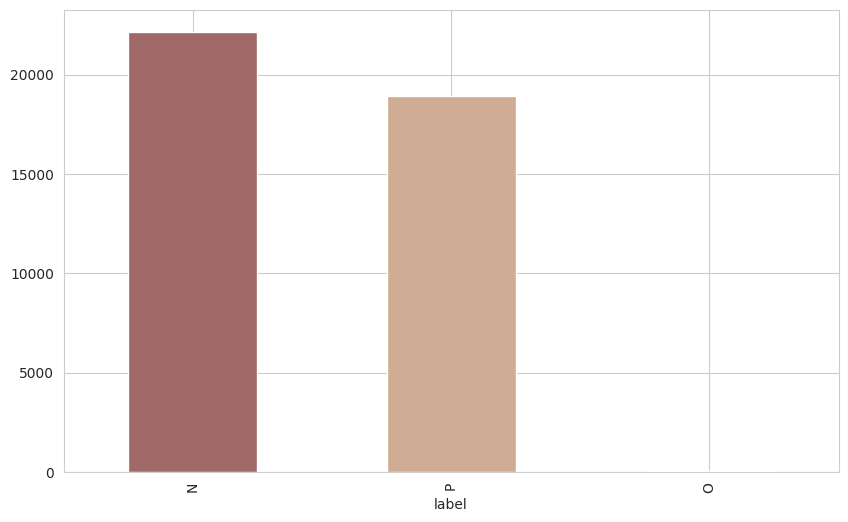

In [ ]:
# Define figure size and style
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create the bar plot with better aesthetics
ax = dataset['label'].value_counts().plot(kind='bar', color=sns.color_palette("pink", len(dataset['label'].unique())))


 Shows the frequency of each unique value in the 'comment' column.

In [ ]:
dataset.value_counts('comment')

,count
comment,
Blacks are such pondlife,5
Muslims are a disgrace,3
Politicians are crap,2
I endorse the genocide of Muslims,2
Politicians are scum,2
...,...
"Illegal Immigrant could be charged With Raping Incapacitated Woman In Kentucky. Shouldn't be released on bail, rightly so, as they probably took 'no' was 'yes' as their women are like slaves to them.",1
Illegal alien invaders* sounds more like it,1
"Illegals are actually citizens with rights, of another country not the US, of course. Slaves were not citizens anywhere hence the constitutional protection",1


Downloads necessary resources for NLTK (Natural Language Toolkit), including 'punkt' and 'stopwords'.

In [ ]:
# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

 Defines a function called preprocess_text to clean and prepare text data. This includes converting to lowercase, removing special characters, tokenization, removing stop words, and stemming. It then applies this function to the 'comment' column and stores the results in a new column called 'preprocessed_tex

In [ ]:
# Preprocessing function
import nltk
nltk.download('punkt_tab')
def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stop words
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    # Stemming
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(word) for word in tokens]

    # Join tokens back into text
    preprocessed_text = ' '.join(tokens)

    return preprocessed_text

# Apply preprocessing to the dataset
dataset['preprocessed_text'] = dataset['comment'].apply(preprocess_text)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Prints the shapes (number of rows and columns) of the training and testing sets (X_train, X_test, y_train, y_test).

In [ ]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(dataset['preprocessed_text'], dataset['label'], test_size=0.2, random_state=42)


Prints the shapes (number of rows and columns) of the training and testing sets (X_train, X_test, y_train, y_test).

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(32915,)
(8229,)
(32915,)
(8229,)
